In [14]:
import urllib.request
import zipfile
import os
from pathlib import Path
import pandas as pd
import tiktoken

import torch
from torch.utils.data import Dataset, DataLoader
from llms_from_scratch.ch04 import GPTModel
from llms_from_scratch.ch05 import download_and_load_gpt2, load_weights_into_gpt
import time
import matplotlib.pyplot as plt

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")


try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


def create_balanced_dataset(df):
    # Count the instances of "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]

    # Randomly sample "ham" instances to match the number of "spam" instances
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)

    # Combine ham "subset" with "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df


df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
balanced_df = create_balanced_dataset(df)
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})


def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df


train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

tokenizer = tiktoken.get_encoding("gpt2")


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate sequences if they are longer than max_length
            self.encoded_texts = [encoded_text[: self.max_length] for encoded_text in self.encoded_texts]

        # Pad sequences to the longest sequence
        self.encoded_texts = [encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) for encoded_text in self.encoded_texts]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long))

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length
        # Note: A more pythonic version to implement this method
        # is the following, which is also used in the next chapter:
        # return max(len(encoded_text) for encoded_text in self.encoded_texts)


num_workers = 0
batch_size = 8

torch.manual_seed(123)

CHOOSE_MODEL = "gpt2-small (124M)"

BASE_CONFIG = {
    "vocab_size": 50257,  # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,  # Dropout rate
    "qkv_bias": True,  # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])


model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")


def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples


def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches


def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter):
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()  # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()  # Calculate loss gradients
            optimizer.step()  # Update model weights using loss gradients
            examples_seen += input_batch.shape[0]  # New: track examples instead of tokens
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch + 1} (Step {global_step:06d}): Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy * 100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy * 100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen


# Same as chapter 5
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.show()

sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.
File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


## Training

In [15]:
def train_model(model, train_loader, val_loader, device):
    start_time = time.time()

    torch.manual_seed(123)

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

    num_epochs = 5
    train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=50, eval_iter=5,
    )

    end_time = time.time()
    execution_time_minutes = (end_time - start_time) / 60
    print(f"Training completed in {execution_time_minutes:.2f} minutes.")

    epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
    examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
    plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses, label="loss")

    epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
    examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
    plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

## Testing

In [16]:
def test_model(model, train_loader, val_loader, test_loader, device):
    train_accuracy = calc_accuracy_loader(train_loader, model, device)
    val_accuracy = calc_accuracy_loader(val_loader, model, device)
    test_accuracy = calc_accuracy_loader(test_loader, model, device)
    print(f"Training accuracy: {train_accuracy*100:.2f}%")
    print(f"Validation accuracy: {val_accuracy*100:.2f}%")
    print(f"Test accuracy: {test_accuracy*100:.2f}%")

## Base Training

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 3.74 mi

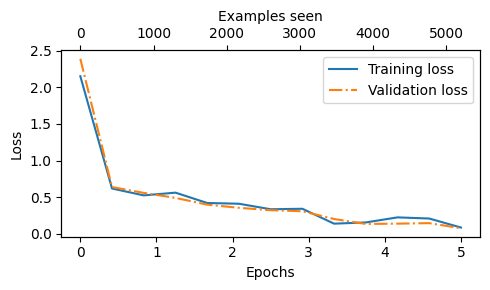

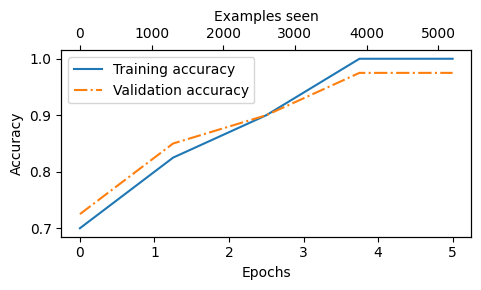

In [17]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)

for param in model.parameters():
    param.requires_grad = False

torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

train_dataset = SpamDataset(csv_file="train.csv", max_length=None, tokenizer=tokenizer)
val_dataset = SpamDataset(csv_file="validation.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)
test_dataset = SpamDataset(csv_file="test.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_model(model, train_loader, val_loader, device)

## Exercise 6.1
Pad the inputs to the maximum number of tokens the model supports and observe how it affects the
predictive performance.

Ep 1 (Step 000000): Train loss 3.840, Val loss 4.255
Ep 1 (Step 000050): Train loss 0.679, Val loss 0.688
Ep 1 (Step 000100): Train loss 0.520, Val loss 0.575
Training accuracy: 75.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.559, Val loss 0.474
Ep 2 (Step 000200): Train loss 0.499, Val loss 0.378
Ep 2 (Step 000250): Train loss 0.477, Val loss 0.385
Training accuracy: 77.50% | Validation accuracy: 80.00%
Ep 3 (Step 000300): Train loss 0.356, Val loss 0.400
Ep 3 (Step 000350): Train loss 0.378, Val loss 0.381
Training accuracy: 85.00% | Validation accuracy: 82.50%
Ep 4 (Step 000400): Train loss 0.298, Val loss 0.358
Ep 4 (Step 000450): Train loss 0.398, Val loss 0.368
Ep 4 (Step 000500): Train loss 0.454, Val loss 0.388
Training accuracy: 87.50% | Validation accuracy: 85.00%
Ep 5 (Step 000550): Train loss 0.360, Val loss 0.383
Ep 5 (Step 000600): Train loss 0.437, Val loss 0.373
Training accuracy: 85.00% | Validation accuracy: 85.00%
Training completed in 80.09 min

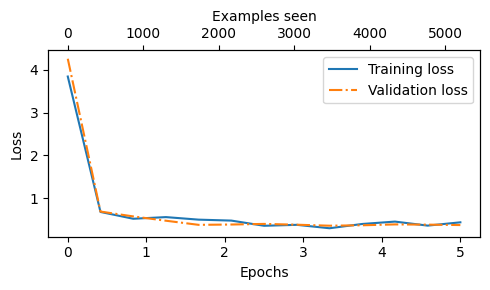

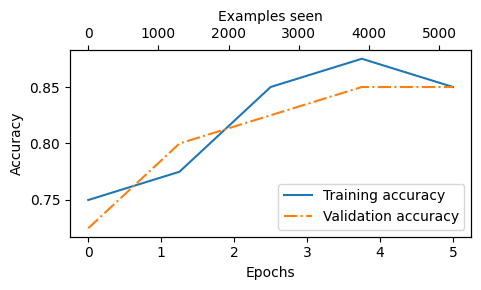

In [18]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)

for param in model.parameters():
    param.requires_grad = False

torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

train_dataset = SpamDataset(csv_file="train.csv", max_length=BASE_CONFIG["context_length"], tokenizer=tokenizer)
val_dataset = SpamDataset(csv_file="validation.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)
test_dataset = SpamDataset(csv_file="test.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_model(model, train_loader, val_loader, device)

## Exercise 6.2
Instead of fine-tuning just the final transformer block, fine-tune the entire model and assess the effect
on predictive performance.

Ep 1 (Step 000000): Train loss 1.314, Val loss 1.495
Ep 1 (Step 000050): Train loss 0.561, Val loss 0.448
Ep 1 (Step 000100): Train loss 0.266, Val loss 0.623
Training accuracy: 97.50% | Validation accuracy: 97.50%
Ep 2 (Step 000150): Train loss 0.207, Val loss 0.096
Ep 2 (Step 000200): Train loss 0.053, Val loss 0.022
Ep 2 (Step 000250): Train loss 0.031, Val loss 0.218
Training accuracy: 95.00% | Validation accuracy: 97.50%
Ep 3 (Step 000300): Train loss 0.107, Val loss 0.077
Ep 3 (Step 000350): Train loss 0.076, Val loss 0.101
Training accuracy: 100.00% | Validation accuracy: 100.00%
Ep 4 (Step 000400): Train loss 0.008, Val loss 0.023
Ep 4 (Step 000450): Train loss 0.065, Val loss 0.029
Ep 4 (Step 000500): Train loss 0.006, Val loss 0.227
Training accuracy: 97.50% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.010, Val loss 0.157
Ep 5 (Step 000600): Train loss 0.001, Val loss 0.147
Training accuracy: 92.50% | Validation accuracy: 95.00%
Training completed in 139.10 

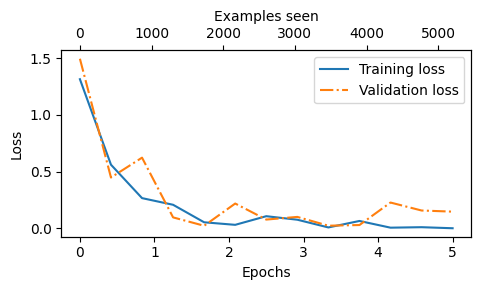

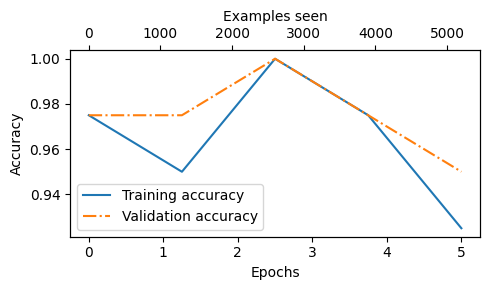

In [19]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)

torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

train_dataset = SpamDataset(csv_file="train.csv", max_length=BASE_CONFIG["context_length"], tokenizer=tokenizer)
val_dataset = SpamDataset(csv_file="validation.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)
test_dataset = SpamDataset(csv_file="test.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_model(model, train_loader, val_loader, device)

## Exercise 6.3
Try fine-tuning the first output token. Notice the changes in predictive performance compared to fine-
tuning the last output token.

Ep 1 (Step 000000): Train loss 1.234, Val loss 1.352
Ep 1 (Step 000050): Train loss 0.710, Val loss 0.711
Ep 1 (Step 000100): Train loss 0.630, Val loss 0.708
Training accuracy: 50.00% | Validation accuracy: 50.00%
Ep 2 (Step 000150): Train loss 0.654, Val loss 0.693
Ep 2 (Step 000200): Train loss 0.631, Val loss 0.682
Ep 2 (Step 000250): Train loss 0.556, Val loss 0.685
Training accuracy: 47.50% | Validation accuracy: 50.00%
Ep 3 (Step 000300): Train loss 0.574, Val loss 0.668
Ep 3 (Step 000350): Train loss 0.508, Val loss 0.664
Training accuracy: 57.50% | Validation accuracy: 50.00%
Ep 4 (Step 000400): Train loss 0.487, Val loss 0.648
Ep 4 (Step 000450): Train loss 0.492, Val loss 0.671
Ep 4 (Step 000500): Train loss 0.470, Val loss 0.642
Training accuracy: 50.00% | Validation accuracy: 50.00%
Ep 5 (Step 000550): Train loss 0.520, Val loss 0.641
Ep 5 (Step 000600): Train loss 0.408, Val loss 0.617
Training accuracy: 47.50% | Validation accuracy: 50.00%
Training completed in 2.80 minu

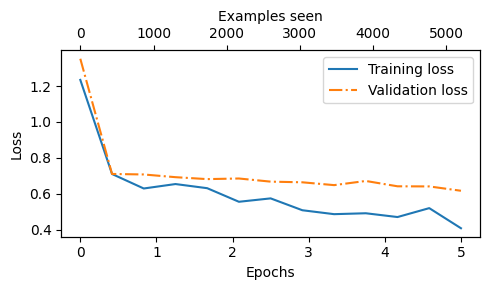

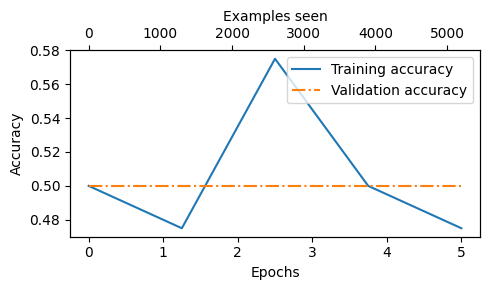

In [20]:
# redefine the loss calculation

# noqa: F811
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, 0, :]  # Logits of FIRST output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss


model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)

for param in model.parameters():
    param.requires_grad = False

torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

train_dataset = SpamDataset(csv_file="train.csv", max_length=None, tokenizer=tokenizer)
val_dataset = SpamDataset(csv_file="validation.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)
test_dataset = SpamDataset(csv_file="test.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_model(model, train_loader, val_loader, device)